# Mass Spring Damper Example
This example shows how to fit a simple linear model.
The data was created previously and loaded from file.
The data are the position of the mass and the force applied.
The neural model mirrors the structure of the physical model.
The network build estimate the future position of the mass.

In [6]:
from nnodely import *
import matplotlib.pyplot as plt
import numpy as np

# Definition of the Model-Structured Neural Netrok
A discrete-time neural approximation of the dynamics is given by
$x_{k+1} = h_x^⊤ x_k + h_F^⊤ F_k$,
where the subscript $(·)_k$ indicates the value of a variable at time step $k$, and bold symbols denote vectors corresponding to temporal windows, i.e., $x_k = [x_{k−n}, \dots , x_k]$ and $F_k = [F_{k−n}, \dots , F_k]$. The parameters $h_x$ and $h_F$ represent the **FIR** filters associated with $x$ and $F$.

In [7]:
# The time history for x
T_x = 0.1

# Define the neural model
x = Input("x")  # MSNN input (Mass position)
F = Input("F")  # MSNN input (Force)
x_free = Fir(
    W_init="init_negexp",
    W_init_params={"first_value": 0.1, "size_index": 0, "lambda": 3},
)(x.tw(T_x))
x_force = Fir(F.tw(T_x))
x_n = Output("x_n", x_free + x_force)

# Add the neural models to the nnodely structure
msd = Modely(seed=42, workspace="saved")
msd.addModel("neural_msd", x_n)

# These functions are used to impose the minimization objectives.
# Here it is minimized the error between the future position of x get from the dataset
# and the estimator designed using the neural network.
# The minimization is imposed via MSE error.
x_t = Input("x_t")  # Real position
msd.addMinimize("x[t]", x_t.next(), x_n)

# Nauralize the model and getting the neural network.
# The sampling time depends on the datasets.
msd.neuralizeModel(0.01)

================================ nnodely Model =================================
{'Constants': {},
 'Functions': {},
 'Info': {'SampleTime': 0.01,
          'nnodely_version': '1.5.2',
          'ns': [10, 1],
          'ntot': 11,
          'num_parameters': 20},
 'Inputs': {'F': {'dim': 1, 'ns': [10, 0], 'ntot': 10, 'tw': [-0.1, 0]},
            'x': {'dim': 1, 'ns': [10, 0], 'ntot': 10, 'tw': [-0.1, 0]},
            'x_t': {'dim': 1, 'ns': [0, 1], 'ntot': 1, 'sw': [0, 1]}},
 'Minimizers': {'x[t]': {'A': 'SamplePart8', 'B': 'Add6', 'loss': 'mse'}},
 'Models': 'neural_msd',
 'Outputs': {'x_n': 'Add6'},
 'Parameters': {'PFir3W': {'dim': 1,
                           'init_fun': {'name': 'init_negexp',
                                        'params': {'first_value': 0.1,
                                                   'lambda': 3,
                                                   'size_index': 0}},
                           'tw': 0.1,
                           'values': [[0.00497

# Data loading and Training
With this lines a dataset in CSV format is loaded from the folder “data”. The column are interpreted using the variable format where the second column is $x$ and $x_r$ and the forth column is $F$. The CSV files are used to build a dataset with a tensor structure compliant with the network architecture. All time windows for each input are generated automatically, and temporal consistency across different files is guaranteed.

A set of parameters default_par are defined and used for training the model.

In [ ]:
data_struct = ["time", ("x", "x_t"), "", "F"]
msd.loadData(
    name="simulations", source="../msd-data/data", format=data_struct, delimiter=";"
)

# Neural network train
param_model = {
    "num_of_epochs": 80,
    "train_batch_size": 128,
    "lr": 0.0005,
    "splits": [70, 20, 10],
}
msd.trainModel(training_params=param_model)

# Save the neural model
msd.exportPythonModel(name="msd_preliminary")

[check_names] The name 'simulations' is already in defined as Dataset but it is overwritten.
============================ nnodely Model Dataset =============================
Dataset Name:                 simulations
Number of files:              100
Total number of samples:      199100
Shape of F:                   (199100, 10, 1)
Shape of x:                   (199100, 10, 1)
Shape of x_t:                 (199100, 1, 1)
[_setup_recurrent_variables] The value of the prediction_samples=0 but the network has no recurrent variables.
======================== nnodely Model Train Parameters ========================
models:                       ['neural_msd']
num of epochs:                80
update per epochs:            1088
└>(n_samples-batch_size)/batch_size+1
shuffle data:                 True
train dataset:                simulations_train
	- batch size:                128
	- num of samples:            139370
validation dataset:           simulations_val
	- batch size:                128

## Closed-Loop Evaluation

The model is rolled out autoregressively, using its predictions as inputs at each step, and the resulting trajectory is compared with the ground truth.

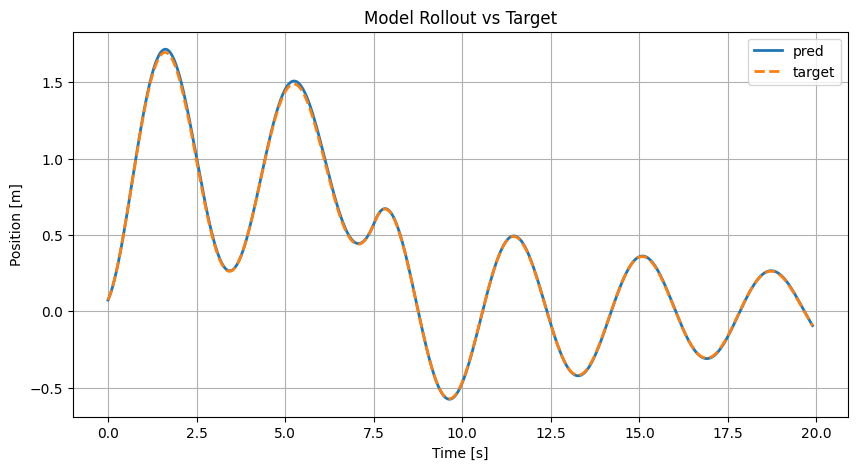

In [ ]:
# Show the network performance on the test dataset
samples = msd.getSamples(dataset="simulations", window=2000 - 10, index=50 * 2000 - 450)
result = msd(
    samples, sampled=True, prediction_samples=2000 - 10, closed_loop={"x": "x_n"}
)

plt.figure(figsize=(10, 5))
t = np.arange(len(result["x_n"])) * 0.01
plt.plot(t, result["x_n"], label="pred", linewidth=2)
plt.plot(t, np.array(samples["x_t"])[:, 0, 0], "--", label="target", linewidth=2)
plt.legend()
plt.grid()
plt.title("Model Rollout vs Target")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.show()

# Recurrent Training
To improve the fitting and enhance robustness, a recurrent training procedure is performed. In this case the network predict the system dynamics for a prediction horizon of 15 s. The framework enables fast prototyping of recurrent networks: in this case, the estimated position $x_n$ is fed back as the input $x$ for the next step.

In [37]:
# Refine weights with recurrent train
msd.trainModel(
    num_of_epochs=10,
    prediction_samples=1500,
    step=500,
    lr=0.00001,
    closed_loop={"x": "x_n"},
    training_params=param_model,
)

# Save the neural model in json format
msd.saveModel(name="msd_final")

======================== nnodely Model Train Parameters ========================
models:                       ['neural_msd']
num of epochs:                10
update per epochs:            54
└>len(train_indexes)//(batch_size+step)
shuffle data:                 True
prediction samples:           1500
step:                         500
closed loop:                  {'x': 'x_n'}
connect:                      {}
train dataset:                simulations_train
	- batch size:                128
	- num of samples:            139370
	- num of first samples:      34370
validation dataset:           simulations_val
	- batch size:                128
	- num of samples:            39820
	- num of first samples:      9820
test dataset:                 simulations_test
	- num of samples:            19910
	- num of first samples:      4910
minimizers:                   {'x[t]': {'A': 'SamplePart8',
                                        'B': 'Add6',
                                        'loss': 'ms

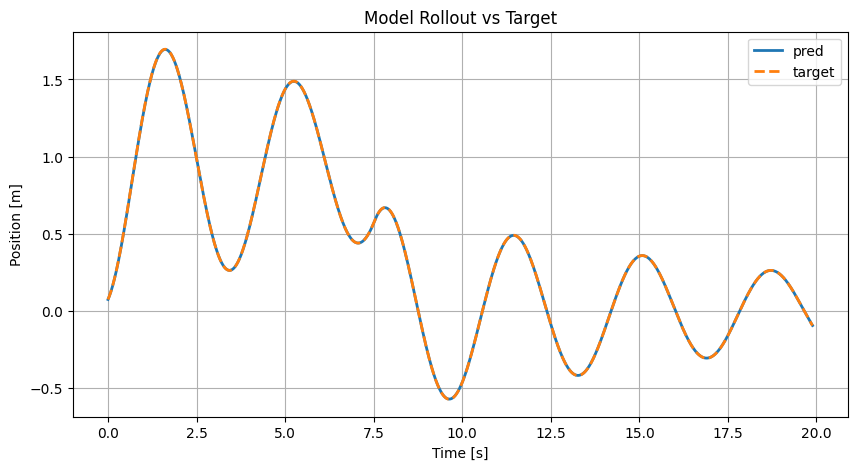

In [ ]:
# Show the network performance on the test dataset after recurrent training
samples = msd.getSamples(dataset="simulations", window=2000 - 10, index=50 * 2000 - 450)
result = msd(
    samples, sampled=True, prediction_samples=2000 - 10, closed_loop={"x": "x_n"}
)

plt.figure(figsize=(10, 5))
t = np.arange(len(result["x_n"])) * 0.01
plt.plot(t, result["x_n"], label="pred", linewidth=2)
plt.plot(t, np.array(samples["x_t"])[:, 0, 0], "--", label="target", linewidth=2)
plt.legend()
plt.grid()
plt.title("Model Rollout vs Target")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.show()

# Definition of the PID controller network
The **Integrate** and **Differentiate** layers directly implement the integral and derivative actions. The resulting neural **PID** model is added to the list of models and trained in series with the forward model: the controller output **F_PID** is connected to the system input $F$, while two closed-loops ensure both the dynamic evolution $('x':'x_n')$ and the update of the measured position $('x_m': 'x_n')$.

In [39]:
x_m = Input("x_m")  # measured position
kp = Parameter("P", values=0.5)
ki = Parameter("I", values=0.5)
kd = Parameter("D", values=0.5)
e = x_t.next() - x_m.next()
c = e * kp + Integrate(e) * ki + Differentiate(e) * kd
controlForce = Output("F_PID", c)
msd.addModel("PID", controlForce)

# Neuralization of the whole models
msd.neuralizeModel()

[neuralizeModel] Connect on Sub13_int14 with sample in the future.
[neuralizeModel] Closed loop on Sub13_int13 with sample in the future.
================================ nnodely Model =================================
{'Constants': {'SampleTime': {'dim': 1, 'values': 0.01}},
 'Functions': {},
 'Info': {'SampleTime': 0.01,
          'nnodely_version': '1.5.2',
          'ns': [10, 1],
          'ntot': 11,
          'num_parameters': 23},
 'Inputs': {'F': {'dim': 1, 'ns': [10, 0], 'ntot': 10, 'tw': [-0.1, 0]},
            'Sub13_int13': {'closedLoop': 'Add20',
                            'dim': 1,
                            'local': 1,
                            'ns': [1, 0],
                            'ntot': 1,
                            'sw': [-1, 0]},
            'Sub13_int14': {'connect': 'Sub13',
                            'dim': 1,
                            'local': 1,
                            'ns': [2, 0],
                            'ntot': 2,
                       

In [40]:
# Train the PID controller
msd.trainModel(
    models="PID",
    closed_loop={"x": "x_n", "x_m": "x_n"},
    connect={"F": "F_PID"},
    prediction_samples=500,
    step=500,
    num_of_epochs=20,
    lr=0.05,
    training_params=param_model,
)

# Print the parameter of the PID
print(
    f"The PID controller kp = {msd.parameters['P']} ki = {msd.parameters['I']} kd = {msd.parameters['D']}"
)

[_setup_recurrent_variables] Closed loop on variable 'x_m' with sample in the future.
======================== nnodely Model Train Parameters ========================
models:                       ['PID']
num of epochs:                20
update per epochs:            166
└>len(train_indexes)//(batch_size+step)
shuffle data:                 True
prediction samples:           500
step:                         500
closed loop:                  {'x': 'x_n', 'x_m': 'x_n'}
connect:                      {'F': 'F_PID'}
train dataset:                simulations_train
	- batch size:                128
	- num of samples:            139370
	- num of first samples:      104370
validation dataset:           simulations_val
	- batch size:                128
	- num of samples:            39820
	- num of first samples:      29820
test dataset:                 simulations_test
	- num of samples:            19910
	- num of first samples:      14910
minimizers:                   {'x[t]': {'A': 'SamplePart

In [ ]:
msd.exportPythonModel(name="msd_final_with_PID")

[check_names] The name 'test_control' is already in defined as Dataset but it is overwritten.
============================ nnodely Model Dataset =============================
Dataset Name:                 test_control
Number of files:              1
Total number of samples:      2001
Shape of x_t:                 (2001, 1, 1)
============== nnodely Model Results for test_control =============
| Loss|        mse        |        FVU        |        AIC        |
|     |    small better   |    small better   |    lower better   |
|-----------------------------------------------------------------|
| x[t]|     3.347e-02     |     2.534e-02     |     -1.073e+03    |
|-----------------------------------------------------------------|
|Total|     3.347e-02     |     2.534e-02     |     -1.073e+03    |
|-----------------------------------------------------------------|


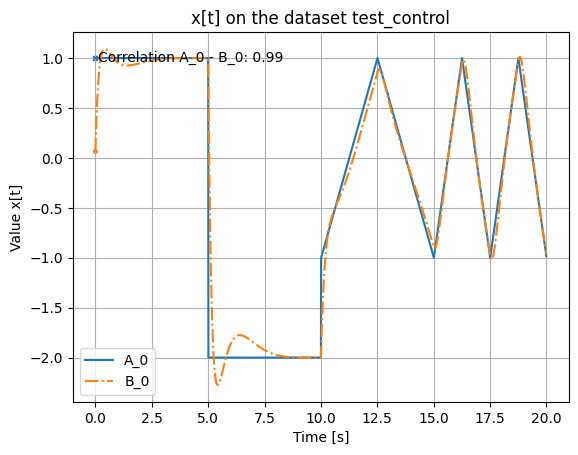

In [46]:
# Test the controller on step and triangular signal
tt = np.linspace(0, 5, int(5 / 0.01), endpoint=False)
data_target = np.concat(
    [
        np.ones(511, dtype=np.float32) * 1.0,  # Step
        -2 * np.ones(500, dtype=np.float32) * 1.0,
        2 * np.abs(2 * (tt * 1 / 5 - np.floor(tt * 1 / 5 + 0.5))) - 1,
        2 * np.abs(2 * (tt * 1 / 2.5 - np.floor(tt * 1 / 2.5 + 0.5))) - 1,
    ]
)
msd.loadData("test_control", {"x_t": data_target})

vis = MPLNotebookVisualizer()
vis.setModely(msd)
vis.showResult("test_control")